# Projet Régression linéaire 

Ce projet a pour but d'implémenter entièrement une régression logistique en python sans utiliser de bibliothèque de machine learning. Nous avons créé un modèle capable de faire une classification binaire (une prédiction 0 ou 1) en :
- codant une régression logistique 
- implémentant une descente de gradient
- en évaluant les performances du modèle
- en interprétant les coefficients obtenus 

In [1]:
#Importation des librairies autorisées
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

## Pré-traitement des données

In [2]:
#Importation du data set
data= pd.read_csv("weather_forecast_data.csv")

In [3]:
#data.head()

In [4]:
#Encodage de la cible : on encode la variable en nombres
data["Rain"]= data["Rain"].map({"no rain": 0, "rain": 1})

In [5]:
#data est bien un DataFrame panda
type(data)

pandas.core.frame.DataFrame

In [6]:
#data.head()
#print(data)

In [7]:
#print(data.isnull().sum())

In [8]:
#print(data.duplicated().sum())

In [9]:
#On cherche les valeurs aberrantes avec le z-score
#from scipy import stats

#Interprétation de la valeurs abberrante
#z = stats.zscore(data["Temperature"])
#outliers = data[(z > 3) | (z < -3)]

In [10]:
#outliers = data[(z > 3) | (z < -3)]
#print(outliers)

In [11]:
#sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
#plt.show()
#correlation

In [12]:
#Séparation des variables

#variable explicative
X = data[["Temperature","Humidity","Cloud_Cover"]]

#variable cible 
Y = data["Rain"]

In [13]:
m = len(X)
indices = np.random.permutation(m)
train_size = int(0.75* m)     # 75% pour l'entraînement
val_size = int(0.05 * m)      # 5% pour la validation
# Le reste (environ 20%) ira au test


train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

X_train = X.iloc[train_idx].reset_index(drop=True)
Y_train = Y.iloc[train_idx].reset_index(drop=True)

# Ensemble de Validation
X_val = X.iloc[val_idx].reset_index(drop=True)
Y_val = Y.iloc[val_idx].reset_index(drop=True)

# Ensemble de Test
X_test = X.iloc[test_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)



In [14]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1875, 3)
(125, 3)
(500, 3)


In [15]:
trainset_size  = len(X_train)
valset_size = len(X_val)

In [16]:
print(X_train.values.shape)

(1875, 3)


In [17]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

## Régression logistique

In [18]:
#Implémentation de la fonction sigmoïde 
def sigmoid(z) : 
    return 1/(1+np.exp(-z))

In [19]:
#print(X_train)
#print(Y_train.values.reshape(-1,1).shape)
#print(a)

In [20]:
y = Y_train.values.reshape(-1,1)

In [21]:
#Fonction coût (log-loss)
def J(a,y) :
    epsilon = 1e-15
    a = np.clip(a, epsilon, 1-epsilon)
    m = len(y) 
    return -1/m * np.sum(y*np.log(a) + (1-y)*np.log(1-a))

In [22]:
#def J(a,Y_train) :
    #return -(1/m)*(Y_train.values.reshape(-1,1) @ np.log(a) + (1-Y_train.values.reshape(-1,1)) @ np.log(1-a))

In [23]:
#pas d'apprentissage
learning_rate=0.01

In [24]:
print(X_train.values.reshape(-1,1))

[[ 1.45486016]
 [-1.30742233]
 [-1.3897905 ]
 ...
 [-1.56715995]
 [ 0.59015916]
 [-1.13467819]]


In [25]:
print(y.shape)
n = X_train.shape[1]
train_costs = []
val_costs = []
w = np.zeros((n,1))
b = 0
print(w)

(1875, 1)
[[0.]
 [0.]
 [0.]]


In [26]:
"""
Cette fonction calcul les gradients dw  et db.

Elle prend en entrée : 
    X : La matrice des variables explicatives (m,n)
    y : vecteur des vraies classes de taille (m,1)
    a : vecteur des probabilités prédites par le modèle de taille (m,1)

"""

# Fonction de calcul des gradients 
def compute_gradients(X, y, a):
    
    #nombre d'observations
    m = len(y)
    
    #Calcul des gradients
    #dw est la moyenne des contributions de chaque variable à
    #l'erreur du modèle
    dw = (1/m) * X.T @ (a-y)
    #db est l'erreur moyenne globale du modèle et indique comment
    #corriger le biais
    db = (1/m)* np.sum(a-y)
    
    return dw, db

## Entraînement de notre modèle 

In [27]:
"""
Cette fonction entraîne un modèle de régression logistique avec une descente de gradient.

    Entrées :
     X_train : variables explicatives de l'ensemble d'entraînement
     Y_train : vraies classes de l'ensemble d'entraînement
     X_val : variables explicatives de l'ensemble de validation
     Y_val : vraies classes de l'ensemble de validation
     learning_rate : pas d'apprentissage, c'est-à-dire la taille des corrections appliquées à w et b
     n_iterations : nombre de fois où l'on répète la descente de gradient

    Sorties :
     w : poids appris par le modèle
     b : biais appris par le modèle
     train_costs : valeurs de la fonction coût sur l'ensemble d'entraînement
     val_costs : valeurs de la fonction coût sur l'ensemble de validation
"""


def train_logistic_regression(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate,
        n_iterations=10000):

    m = len(X_train)
    n = X_train.shape[1]

    w = np.zeros((n,1))
    b = 0

    train_costs = []
    val_costs = []

    y_train = Y_train.values.reshape(-1,1)
    y_val = Y_val.values.reshape(-1,1)

    for i in range(n_iterations):

        # train
        z_train = X_train.values @ w + b
        a_train = sigmoid(z_train)

        train_cost = J(a_train,y_train)
        train_costs.append(train_cost)

        # validation
        z_val = X_val.values @ w + b
        a_val = sigmoid(z_val)

        val_cost = J(a_val,y_val)
        val_costs.append(val_cost)

        # gradients
        dw = (1/m) * X_train.values.T @ (a_train-y_train)
        db = (1/m) * np.sum(a_train-y_train)

        # mise à jour
        w -= learning_rate * dw
        b -= learning_rate * db

    return w,b,train_costs,val_costs

In [28]:
# Entraînement du modèle de régression logistique à l'aide de la descente de gradient.
# La fonction retourne les paramètres optimisés (w et b) ainsi que l'évolution
# de la fonction coût sur les ensembles d'entraînement et de validation.

# w : poids finaux appris pour chaque variable.
# b : biais final appris par le modèle.
# train_costs : historique du coût sur l'ensemble d'entraînement.
# val_costs : historique du coût sur l'ensemble de validation.

w,b,train_costs,val_costs = train_logistic_regression(
    X_train,
    Y_train,
    X_val,
    Y_val,
    learning_rate=0.01,
    n_iterations=10000
)

In [29]:
print(w)
print(b)

[[-1.29178662]
 [ 1.80340804]
 [ 1.59613613]]
-3.6475237460271663


## Visulisation de l'apprentissage du modèle 
### Graphique des coûts 

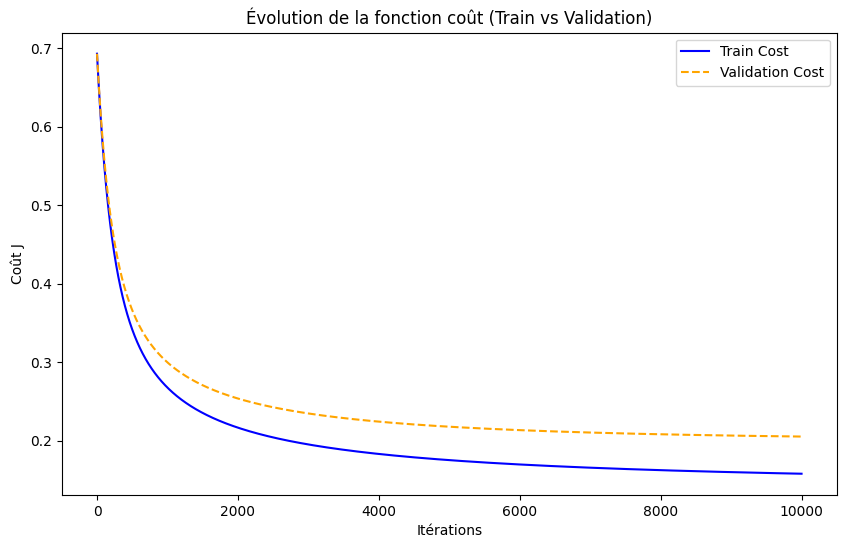

In [30]:
# Affichage du graphique comparatif (Source [5, 6])
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train Cost", color='blue')
plt.plot(val_costs, label="Validation Cost", color='orange', linestyle='--')
plt.title("Évolution de la fonction coût (Train vs Validation)")
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.legend()
plt.show()

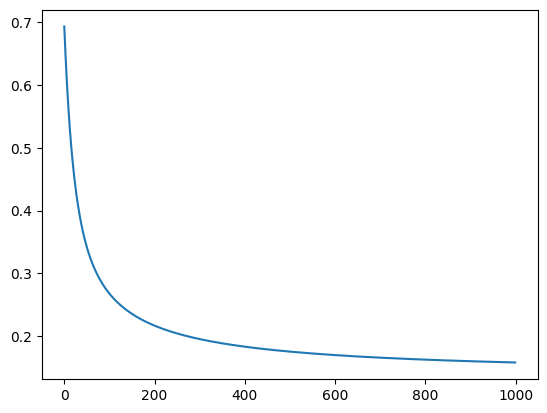

In [31]:
plt.plot(train_costs[::10])

In [32]:
#test

In [33]:
z_test = X_test.values @ w + b
a_test = sigmoid(z_test)
TN = FP = FN = TP = 0

In [34]:
y_true = Y_test.values.reshape(-1,1)
y_pred = (a_test >= 0.5).astype(int)

for i in range(len(y_true)):
    if y_true[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y_true[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y_true[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y_true[i] == 1 and y_pred[i] == 0:
        FN += 1

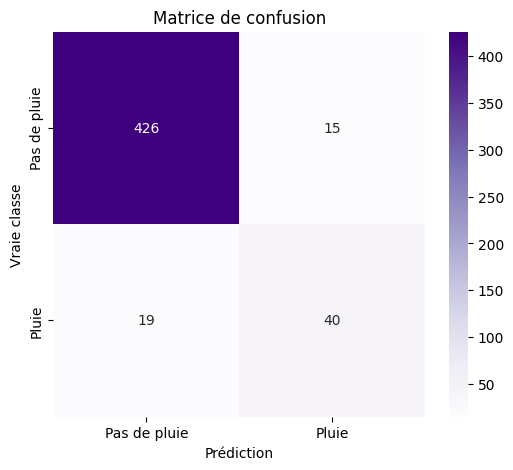

In [35]:
cm = np.array([[TN, FP],
               [FN, TP]])
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=True,
    xticklabels=["Pas de pluie", "Pluie"],
    yticklabels=["Pas de pluie", "Pluie"]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

In [36]:
#on va évalué les performances

#mesure le total du nombre de pourcentage correct
accuracy=((TP+TN)/(TP+TN+FP+FN))*100

#mesure combien des cas predits, sont vraiment des cas pluies
precision= (TP/(TP+FP))*100
#dectection de nombre de vrais de pluie
recall=(TP/(TP+FN))*100
#Le F1-score est la moyenne harmonique entre précision et rappel
f1 = (2 * ((precision * recall) / (precision + recall)))

print(f"Accuracy  : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 93.2000
Précision : 72.7273
Rappel    : 67.7966
F1-score  : 70.1754


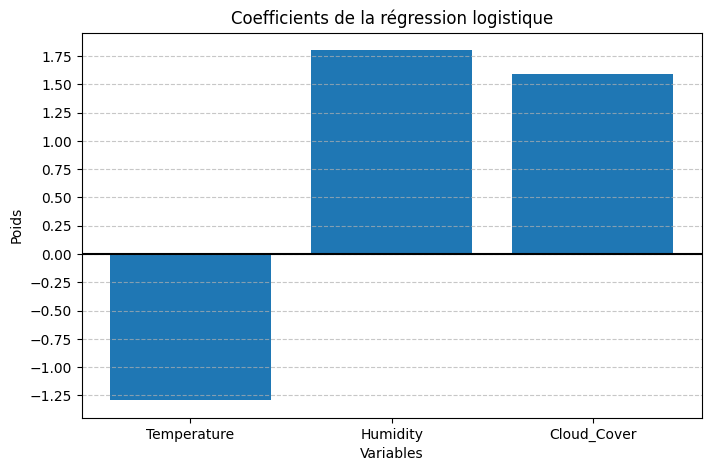

In [37]:
variables = X_train.columns

plt.figure(figsize=(8,5))
plt.bar(variables, w.flatten())
plt.axhline(0, color='black')

plt.gca().yaxis.set_major_locator(MultipleLocator(0.25))

plt.title("Coefficients de la régression logistique")
plt.ylabel("Poids")
plt.xlabel("Variables")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()